<a href="https://colab.research.google.com/github/cn0r19/Machine_Learning/blob/main/HW3/churn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TASK 1**

In [87]:
import pandas as pd

# load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

**TASK 2**

In [88]:
import pandas as pd

# display the first 5 rows of the whole dataset
print('\n--- First 5 Rows ---\n')
display(df.head())

# display the information for each feature in the dataset
print('\n--- Dataframe Info ---\n')
df.info()

# display the statistical information relating to the int features
print('\n--- Summary Statistics ---\n')
display(df.describe())


--- First 5 Rows ---



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- Dataframe Info ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling 

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**TASK 3**

In [89]:
import pandas as pd

# drops the customer id from the dataframe
df = df.drop('customerID', axis=1)

**TASK 4**

In [90]:
import pandas as pd

# convert total charges to float and replace missing values with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

**TASK 5**

In [91]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# separate the categorical and numerical data
categorical_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
                        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                        'Contract', 'PaperlessBilling', 'PaymentMethod']
numerical_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

# Numerical transformation pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical transformation pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

**TASK 6**

In [92]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import SGDClassifier

# Assemble full pipeline with preprocessing and classifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=42))
])

print('Pipeline constructed correctly!')

Pipeline constructed correctly!


**TASK 7**

Pipeline constructed correctly!

Training features shape (80/20): (5634, 19)
Testing features shape (80/20): (1409, 19)

Training features shape (70/30): (4930, 19)
Testing features shape (70/30): (2113, 19)

Training features shape (60/40): (4225, 19)
Testing features shape (60/40): (2818, 19)

Classification Report of 80/20 Split:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1036
           1       0.66      0.58      0.62       373

    accuracy                           0.81      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.80      0.81      0.81      1409



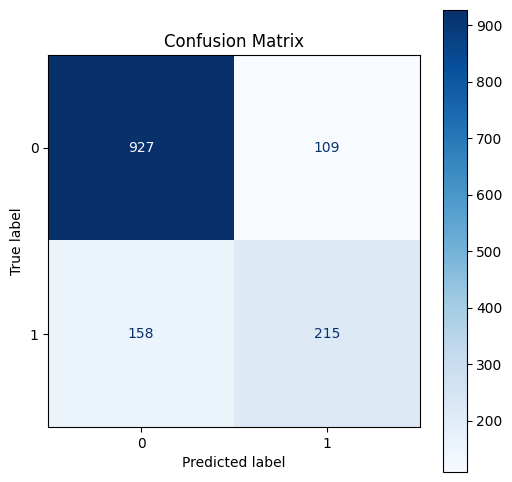

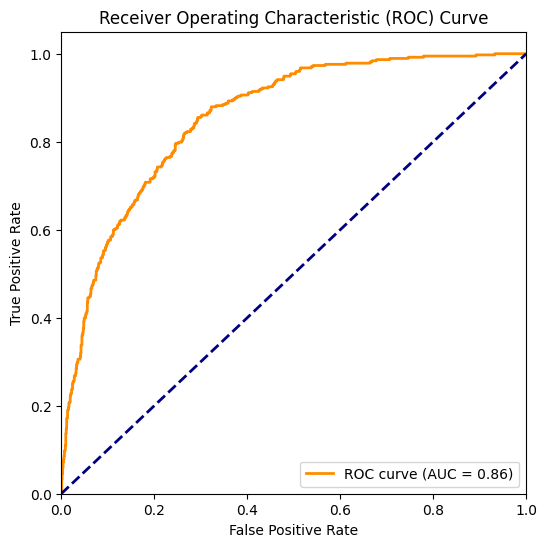


Classification Report of 70/30 Split:
              precision    recall  f1-score   support

           0       0.79      0.96      0.87      1539
           1       0.73      0.32      0.44       574

    accuracy                           0.78      2113
   macro avg       0.76      0.64      0.66      2113
weighted avg       0.78      0.78      0.75      2113



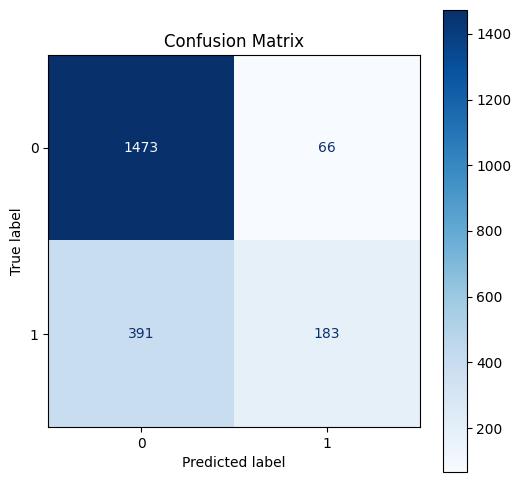

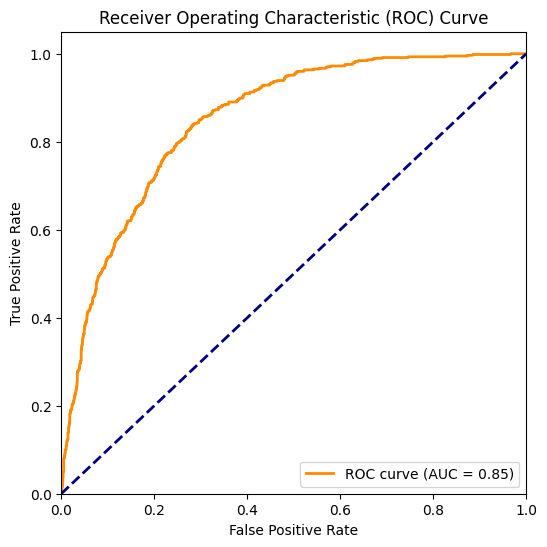


Classification Report of 60/40 Split:
              precision    recall  f1-score   support

           0       0.89      0.82      0.86      2069
           1       0.60      0.72      0.65       749

    accuracy                           0.80      2818
   macro avg       0.74      0.77      0.76      2818
weighted avg       0.81      0.80      0.80      2818



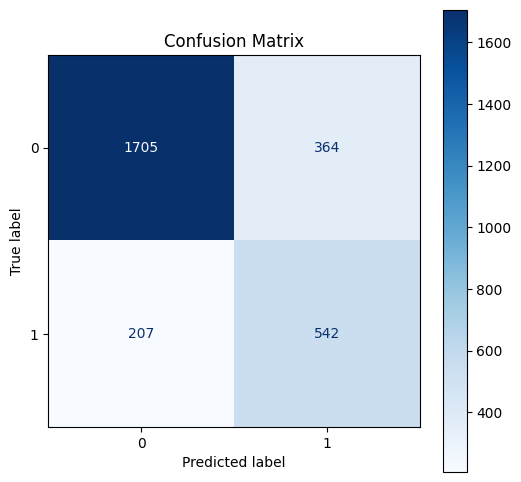

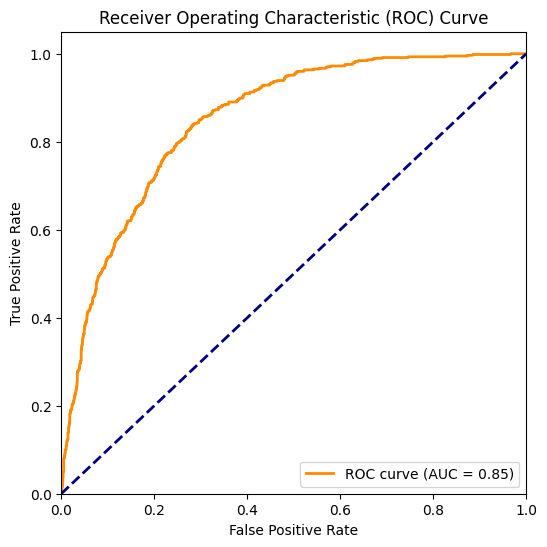

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

# separate target from rest of dataset
X = df.drop('Churn', axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})

# Split data into training and testing sets
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2, random_state=42)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.3, random_state=42)
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size=0.4, random_state=42)

# separate the categorical and numerical data
categorical_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
                        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                        'Contract', 'PaperlessBilling', 'PaymentMethod']
numerical_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

print('Pipeline constructed correctly!')
print(f"\nTraining features shape (80/20): {X_train1.shape}")
print(f"Testing features shape (80/20): {X_test1.shape}")
print(f"\nTraining features shape (70/30): {X_train2.shape}")
print(f"Testing features shape (70/30): {X_test2.shape}")
print(f"\nTraining features shape (60/40): {X_train3.shape}")
print(f"Testing features shape (60/40): {X_test3.shape}\n")

# Fit the entire pipeline on the training data (80/20)
pipeline.fit(X_train1, y_train1)

# Generate predictions and probability scores on the test set
y_pred1 = pipeline.predict(X_test1)
y_scores1 = pipeline.predict_proba(X_test1)[:, 1]

# Print classification report for 80/20
print('Classification Report of 80/20 Split:')
print(classification_report(y_test1, y_pred1))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(pipeline, X_test1, y_test1, ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC Curve and ROC-AUC
fpr, tpr, thresholds = roc_curve(y_test1, y_scores1)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
print('\n')
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Fit the entire pipeline on the training data (70/30)
pipeline.fit(X_train2, y_train2)

# Generate predictions and probability scores on the test set
y_pred2 = pipeline.predict(X_test2)
y_scores2 = pipeline.predict_proba(X_test2)[:, 1]

# Print classification report for 70/30
print('\nClassification Report of 70/30 Split:')
print(classification_report(y_test2, y_pred2))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(pipeline, X_test2, y_test2, ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC Curve and ROC-AUC
fpr, tpr, thresholds = roc_curve(y_test2, y_scores2)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
print('\n')
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Fit the entire pipeline on the training data (60/40)
pipeline.fit(X_train3, y_train3)

# Generate predictions and probability scores on the test set
y_pred3 = pipeline.predict(X_test3)
y_scores3 = pipeline.predict_proba(X_test3)[:, 1]

# Print classification report for 60/40
print('\nClassification Report of 60/40 Split:')
print(classification_report(y_test3, y_pred3))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(pipeline, X_test3, y_test3, ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC Curve and ROC-AUC
fpr, tpr, thresholds = roc_curve(y_test2, y_scores2)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
print('\n')
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

**TASK 8**

In [94]:
import pandas as pd

# Fit the entire pipeline on the training data (80/20)
pipeline.fit(X_train1, y_train1)

# Extract feature names from the preprocessor step
cat_encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features).tolist()

# Combine numerical and encoded categorical feature names
all_feature_names = numerical_features + encoded_cat_features

# Retrieve coefficients from the SGDClassifier step
coefficients = pipeline.named_steps['classifier'].coef_[0]

# Create a DataFrame to view feature importance
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

# Display top features pushing toward Yes or No
print("Top features pushing toward Yes (80/20):")
print(feature_importance_df.head(10))

print("\nTop features pushing toward No (80/20):")
print(feature_importance_df.tail(10))

# Fit the entire pipeline on the training data (70/30)
pipeline.fit(X_train2, y_train2)

# Extract feature names from the preprocessor step
cat_encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features).tolist()

# Combine numerical and encoded categorical feature names
all_feature_names = numerical_features + encoded_cat_features

# Retrieve coefficients from the SGDClassifier step
coefficients = pipeline.named_steps['classifier'].coef_[0]

# Create a DataFrame to view feature importance
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

# Display top features pushing toward Yes or No
print("\nTop features pushing toward Yes (70/30):")
print(feature_importance_df.head(10))

print("\nTop features pushing toward No (70/30):")
print(feature_importance_df.tail(10))

# Fit the entire pipeline on the training data (60/40)
pipeline.fit(X_train3, y_train3)

# Extract feature names from the preprocessor step
cat_encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features).tolist()

# Combine numerical and encoded categorical feature names
all_feature_names = numerical_features + encoded_cat_features

# Retrieve coefficients from the SGDClassifier step
coefficients = pipeline.named_steps['classifier'].coef_[0]

# Create a DataFrame to view feature importance
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

# Display top features pushing toward Yes or No
print("\nTop features pushing toward Yes (60/40):")
print(feature_importance_df.head(10))

print("\nTop features pushing toward No (60/40):")
print(feature_importance_df.tail(10))

Top features pushing toward Yes (80/20):
                        Feature  Coefficient
16  InternetService_Fiber optic     1.107267
36      Contract_Month-to-month     1.075401
35          StreamingMovies_Yes     0.704609
18            OnlineSecurity_No     0.667062
8                 Dependents_No     0.630628
40         PaperlessBilling_Yes     0.592810
32              StreamingTV_Yes     0.572890
14            MultipleLines_Yes     0.563474
3                  TotalCharges     0.549815
11             PhoneService_Yes     0.542286

Top features pushing toward No (80/20):
                                 Feature  Coefficient
19    OnlineSecurity_No internet service     0.108926
25  DeviceProtection_No internet service     0.108926
33                    StreamingMovies_No     0.079292
44            PaymentMethod_Mailed check     0.071239
0                          SeniorCitizen     0.033853
12                      MultipleLines_No    -0.021188
15                   InternetService_DSL    -